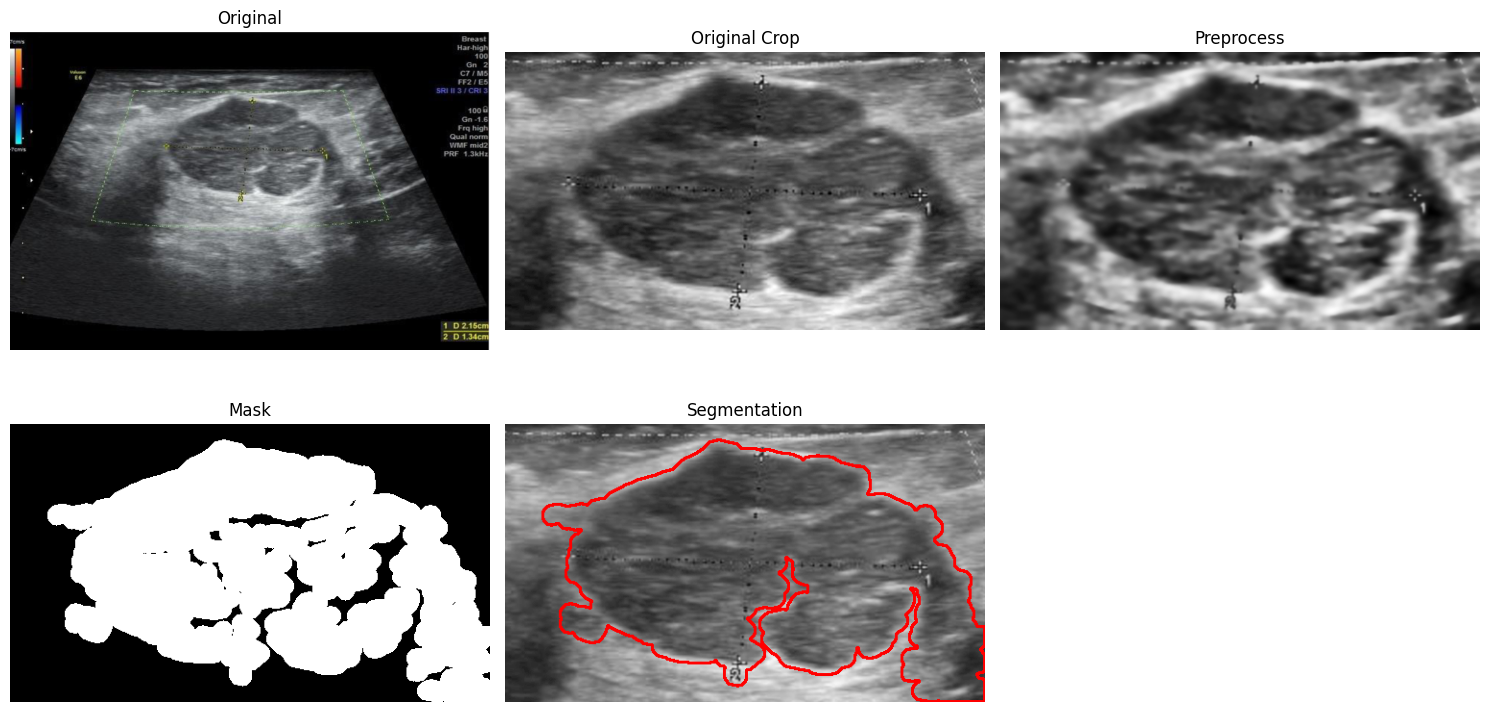

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Load + crop
img = cv2.imread("tugas segmentasi.png", cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(cv2.imread("tugas segmentasi.png"), cv2.COLOR_BGR2RGB)
roi = img[130:420, 300:800]

# Preprocess
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
smooth = cv2.bilateralFilter(clahe.apply(roi), 9, 75, 75)
smooth = cv2.GaussianBlur(smooth, (3, 3), 0)

# Threshold (Otsu + adaptive)
_, otsu = cv2.threshold(smooth, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
adaptive = cv2.adaptiveThreshold(smooth, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 25, 3)
mask = cv2.bitwise_and(otsu, adaptive)

# Morphology
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 7))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
mask = ndimage.binary_fill_holes(mask).astype(np.uint8) * 255

# Ambil objek terbesar
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = np.zeros_like(mask)
if contours:
    biggest = max(contours, key=cv2.contourArea)
    cv2.drawContours(result, [biggest], -1, 255, -1)
    result = cv2.dilate(result, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)))

# Overlay countours di gambar asli
final_contours, _ = cv2.findContours(result, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)
cv2.drawContours(overlay, final_contours, -1, (255, 0, 0), 2)

# Output
titles = ["Original","Original Crop", "Preprocess", "Mask", "Segmentation"]
images = [img_rgb, roi, smooth, result, overlay]
plt.figure(figsize=(15, 8))
for i, (t, im) in enumerate(zip(titles, images), 1):
    plt.subplot(2, 3, i)
    plt.imshow(im, cmap=None if im.ndim == 3 else "gray")
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()
